In [1]:
# %matplotlib widget
import sys
sys.path.append('..')

import os
import sys
import numpy as np
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
from mpl_toolkits import mplot3d
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
import math
from IPython.display import HTML
from tqdm import tqdm
import random
from numpy.lib import recfunctions as rfn

from sklearn.cluster import DBSCAN
from scipy.interpolate import interp1d
from scipy.spatial import KDTree
from scipy.interpolate import interpn
# import cupy as cp
import time
import numba as nb

# 画图部分
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid
from functools import partial
import matplotlib.cm as cm

# ROC曲线部分
from sklearn.metrics import roc_curve, auc
from sklearn import metrics

# 插值
from scipy.interpolate import griddata

# 系数拟合部分
from scipy.optimize import curve_fit
from sklearn import svm

In [2]:
import numpy as np  
from scipy.spatial import KDTree  

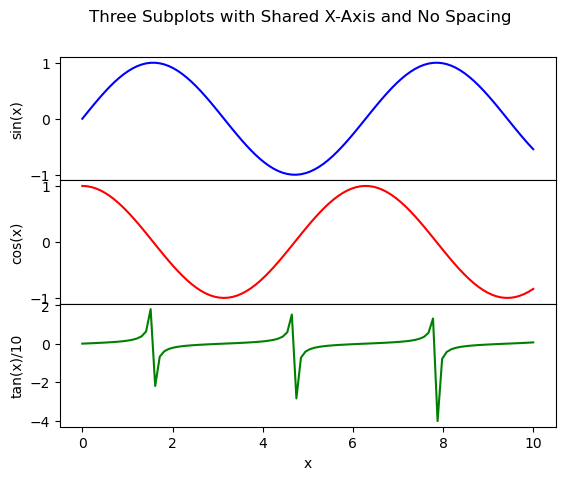

In [4]:
import matplotlib.pyplot as plt  

# 创建数据  
x = np.linspace(0, 10, 100)  
y1 = np.sin(x)  
y2 = np.cos(x)  
y3 = np.tan(x) / 10  # 将tan(x)缩小以避免过大的值  
  
# 创建包含三个子图的图形，并设置它们之间的间距为0  
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, gridspec_kw={'hspace': 0})  
  
# 绘制第一个子图  
ax1.plot(x, y1, 'b-')  
ax1.set_ylabel('sin(x)')  
  
# 绘制第二个子图，并移除x轴刻度标签以避免重复  
ax2.plot(x, y2, 'r-')  
ax2.set_ylabel('cos(x)')  
ax2.tick_params(axis='x', labelbottom=False)  
  
# 绘制第三个子图  
ax3.plot(x, y3, 'g-')  
ax3.set_ylabel('tan(x)/10')  
ax3.set_xlabel('x')  # 只在最后一个子图上设置x轴标签  
  
# 设置标题（可选）  
plt.suptitle('Three Subplots with Shared X-Axis and No Spacing')  
  
# 显示图形  
plt.show()

In [120]:
def KD_tree_nD(type0_points, type1_points, query_points, k=100):  
    """  
    为给定的查询点找到最接近的k个点，分别来自类型0和类型1。  
      
    参数:  
    type0_points: NumPy数组，形状为(n0, N)，表示类型1的N维坐标。  
    type1_points: NumPy数组，形状为(n1, N)，表示类型2的N维坐标。  
    query_points: NumPy数组，形状为(m, N)，表示查询点的N维坐标。  
    k: 整数，表示要找到的最接近的点的数量。  
      
    返回:  
    一个NumPy数组，形状为(m, k, N)和(m, k)，表示每个查询点的最接近的类型1和类型2的点的坐标以及对应的类型标签。  
    """  
    # 检查输入点类型是否符合
    Nd = type0_points.shape[1]
    if type0_points.shape[1] != type1_points.shape[1] or type0_points.shape[1] != query_points.shape[1]:
        raise ValueError("type0_points,type1_points和query_points的维数必须一致")  
    
    # 为类型0和类型1的点构建KD树  
    sample_points = np.concatenate([type0_points, type1_points])
    sample_points_ = np.concatenate([type0_points, type1_points])
    sample_tags = np.concatenate([np.zeros(len(type0_points)),np.ones(len(type1_points))])
    tree = KDTree(sample_points)  
      
    # 初始化结果数组  
    closest_points = np.zeros((len(query_points), k, Nd))   
    closest_type = np.zeros((len(query_points), k))   
      
    # 对每个查询点找到最接近的k个点  
    for i, query in enumerate(query_points):  
        distances, indices = tree.query(query, k=k)  
        closest_points[i] = sample_points_[indices]  
        closest_type[i] = sample_tags[indices]  
      
    # 返回结果，包括坐标和类型标签（这里用1和2表示）  
    return closest_points, closest_type
  

In [177]:
sample0 = np.random.normal(loc=0.0, scale=1.0, size=(10000,2))
sample1 = np.random.normal(loc=0.0, scale=1.0, size=(10000,2))
sample1 += np.array([4,4])

query_points = np.random.normal(loc=0.0, scale=1.0, size=(1000,2))
query_points += np.array([2,2])

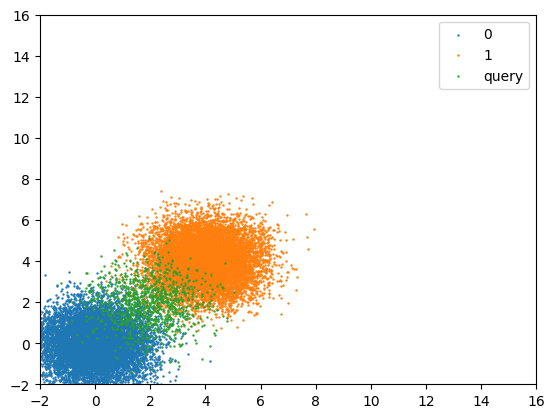

In [178]:
# 绘制散点图  
plt.scatter(sample0[:,0], sample0[:,1],s = 0.5,label = "0")  
plt.scatter(sample1[:,0], sample1[:,1],s = 0.5,label = "1") 
plt.scatter(query_points[:,0], query_points[:,1],s = 0.5,label = "query") 
plt.legend()
plt.xlim(-2,16)
plt.ylim(-2,16)
# 显示图表  
plt.show()

In [179]:
k_near = 30

k_close, k_close_type = KD_tree_nD(sample0, sample1, query_points, k=k_near)

In [180]:
query_type = np.sum(k_close_type,axis = 1) > (k_near / 2)

In [181]:
real_mask = (query_points[:,0] + query_points[:,1]) > 4

In [182]:
strage_mask = (real_mask == False) * (query_type == True)
real_mask.shape,query_type.shape,strage_mask.shape

((1000,), (1000,), (1000,))

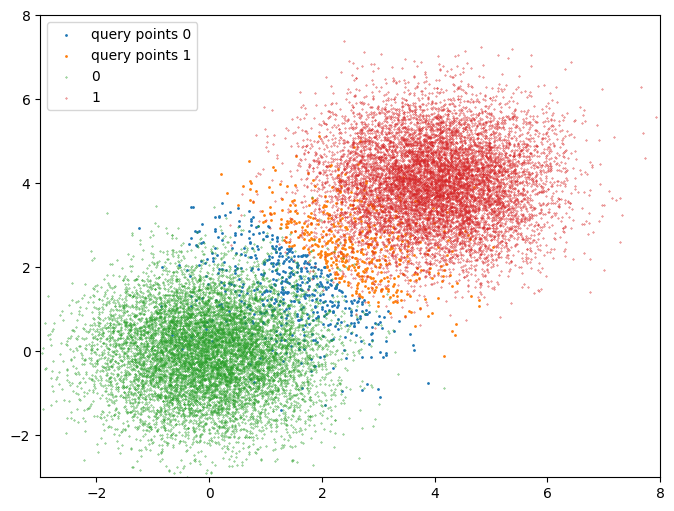

In [189]:
fig = plt.figure(figsize=(8, 6), dpi=100)

#plt.scatter(query_points[strage_mask][0][0], query_points[strage_mask][0][1],s = 1.5,label = "strange points") 
plt.scatter(query_points[~query_type][:,0], query_points[~query_type][:,1],s = 1,label = "query points 0") 
plt.scatter(query_points[query_type][:,0], query_points[query_type][:,1],s = 1,label = "query points 1") 
plt.scatter(sample0[:,0], sample0[:,1],s = 0.1,label = "0")  
plt.scatter(sample1[:,0], sample1[:,1],s = 0.1,label = "1") 
plt.legend()
plt.xlim(-3,8)
plt.ylim(-3,8)
# 显示图表  
plt.show()

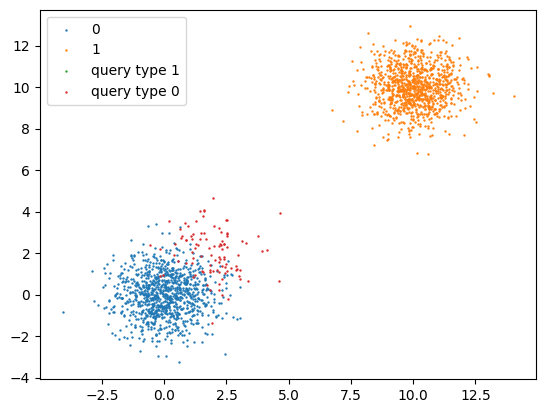

In [161]:
# 绘制散点图  
plt.scatter(sample0[:,0], sample0[:,1],s = 0.5,label = "0")  
plt.scatter(sample1[:,0], sample1[:,1],s = 0.5,label = "1") 
plt.scatter(query_points[query_type == True][:,0], query_points[query_type == True][:,1],s = 0.5,label = "query type 1") 
plt.scatter(query_points[query_type == False][:,0], query_points[query_type == False][:,1],s = 0.5,label = "query type 0") 
plt.legend()
# 显示图表  
plt.show()

KNN query time
====

In [193]:
import psutil 

# 获取当前进程  
process = psutil.Process()  
  
# 获取内存占用信息  
memory_info = process.memory_info()  
  
# 打印内存占用情况（单位是字节）  
print(f"RSS (Resident Set Size): {memory_info.rss} bytes")  
print(f"VMS (Virtual Memory Size): {memory_info.vms} bytes")  
print(f"Shared Memory: {memory_info.shared} bytes")  
print(f"Text (code): {memory_info.text / 1e6} MB")  
print(f"Data + Stack: {memory_info.data / 1e6} MB")  
print(f"Dirty Pages: {memory_info.dirty} bytes")

RSS (Resident Set Size): 302678016 bytes
VMS (Virtual Memory Size): 1444765696 bytes
Shared Memory: 105304064 bytes
Text (code): 2.039808 MB
Data + Stack: 323.289088 MB
Dirty Pages: 0 bytes


每次查询100个点，不同的DEsample规模的计算时间

In [201]:
time_list_1e4query = []
DE_size_list = np.arange(1e7,1e8,1e7)

for DE_size in DE_size_list:
    start_time = time.time()  
    sample0 = np.random.normal(loc=0.0, scale=1.0, size=(int(1e6),2))
    sample1 = np.random.normal(loc=0.0, scale=1.0, size=(int(DE_size),2))
    sample1 += np.array([4,4])
    
    query_points = np.random.normal(loc=0.0, scale=1.0, size=(int(1e4),2))
    
    k_near = 30
    k_close, k_close_type = KD_tree_nD(sample0, sample1, query_points, k=k_near)

    end_time = time.time()  
    print("Time consumption:{} s. DE size:{} .".format(end_time - start_time, int(DE_size)))
    time_list_1e4query.append(end_time - start_time)
    # 获取当前进程  
    process = psutil.Process()  
      
    # 获取内存占用信息  
    memory_info = process.memory_info()  
    
    print(f"Data + Stack: {memory_info.data / 1e6} MB")  

Time consumption:7.438197612762451 s. DE size:10000000 .
Data + Stack: 8978.866176 MB
Time consumption:14.515750169754028 s. DE size:20000000 .
Data + Stack: 9145.511936 MB
Time consumption:21.838945627212524 s. DE size:30000000 .
Data + Stack: 9305.509888 MB
Time consumption:28.13945984840393 s. DE size:40000000 .
Data + Stack: 9470.312448 MB
Time consumption:38.31549572944641 s. DE size:50000000 .
Data + Stack: 9630.3104 MB
Time consumption:45.25937533378601 s. DE size:60000000 .
Data + Stack: 9790.312448 MB
Time consumption:53.5299346446991 s. DE size:70000000 .
Data + Stack: 9950.3104 MB
Time consumption:60.85380816459656 s. DE size:80000000 .
Data + Stack: 10110.32064 MB
Time consumption:71.04930329322815 s. DE size:90000000 .
Data + Stack: 10270.318592 MB


每次固定1e7个DE sample，查询不同规模的时间

In [203]:
time_list_1e7DE = []
query_size_list = np.arange(1e5,1e6,1e5)

for query_size in query_size_list:
    sample0 = np.random.normal(loc=0.0, scale=1.0, size=(int(1e6),2))
    sample1 = np.random.normal(loc=0.0, scale=1.0, size=(int(1e7),2))
    sample1 += np.array([4,4])
    
    query_points = np.random.normal(loc=0.0, scale=1.0, size=(int(query_size),2))
    
    start_time = time.time()  
    k_near = 30
    k_close, k_close_type = KD_tree_nD(sample0, sample1, query_points, k=k_near)
    end_time = time.time()  
    
    print("Time consumption:{} s. Query size:{} .".format(end_time - start_time, int(query_size)))
    time_list_1e7DE.append(end_time - start_time)
    # 获取当前进程  
    process = psutil.Process()  
      
    # 获取内存占用信息  
    memory_info = process.memory_info()  
    
    print(f"Data + Stack: {memory_info.data / 1e6} MB")  

Time consumption:9.420665740966797 s. Query size:100000 .
Data + Stack: 9064.742912 MB
Time consumption:12.085300207138062 s. Query size:200000 .
Data + Stack: 9093.070848 MB
Time consumption:15.092662572860718 s. Query size:300000 .
Data + Stack: 9203.073024 MB
Time consumption:17.943700313568115 s. Query size:400000 .
Data + Stack: 9287.94624 MB
Time consumption:20.998557329177856 s. Query size:500000 .
Data + Stack: 9359.941632 MB
Time consumption:23.912187099456787 s. Query size:600000 .
Data + Stack: 9431.945216 MB
Time consumption:26.95628333091736 s. Query size:700000 .
Data + Stack: 9503.944704 MB
Time consumption:29.82239532470703 s. Query size:800000 .
Data + Stack: 9577.549824 MB
Time consumption:32.798794984817505 s. Query size:900000 .
Data + Stack: 9649.545216 MB


In [204]:
time_list_1e7DE

[9.420665740966797,
 12.085300207138062,
 15.092662572860718,
 17.943700313568115,
 20.998557329177856,
 23.912187099456787,
 26.95628333091736,
 29.82239532470703,
 32.798794984817505]

In [205]:
time_list_1e4query

[7.438197612762451,
 14.515750169754028,
 21.838945627212524,
 28.13945984840393,
 38.31549572944641,
 45.25937533378601,
 53.5299346446991,
 60.85380816459656,
 71.04930329322815]